In [1]:
# EXP1 = "G6sulfur"   # minuend
EXP1 = "1pctCO2-bgc"     # minuend (delta = EXP1 - EXP2)
EXP2 = "piControl"       # subtrahend

import numpy as np
import xarray as xr
import cftime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import xarray as xr
from pathlib import Path

import sys
import os

analysis_path = os.path.abspath("../20260112_Basic_Analysis")
sys.path.append(analysis_path)

import myfunctions as mf

#Package to suppress Python warnings
import warnings
warnings.filterwarnings("ignore")

import xesmf as xe
import xarray as xr
import numpy as np

# =========================
# Base CEDA paths
# =========================

CEDA_BASE = Path("/badc/cmip6/data/CMIP6")

#Model Names
MODELS = {
    "UKESM1-0-LL":  {"institution": "MOHC",         "ensemble": "r1i1p1f2",  "grid": "gn",},
    "CNRM-ESM2-1":  {"institution": "CNRM-CERFACS", "ensemble": "r1i1p1f2",  "grid": "gr",},
    "MPI-ESM1-2-LR":{"institution": "MPI-M",        "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2":        {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "CESM2-WACCM":  {"institution": "NCAR",         "ensemble": "r1i1p1f1",  "grid": "gn",},
    "IPSL-CM6A-LR": {"institution": "IPSL",         "ensemble": "r1i1p1f1",  "grid": "gr",},
}

# =========================
# Experiment registry
# =========================

EXP_REGISTRY = {
    "piControl": {"project": "CMIP",        "scenario": "piControl"},
    "1pctCO2-bgc": {"project": "C4MIP",        "scenario": "1pctCO2-bgc"},
    "HIST":      {"project": "CMIP",        "scenario": "historical"},
    "SSP245":    {"project": "ScenarioMIP", "scenario": "ssp245"},
    "SSP585":    {"project": "ScenarioMIP", "scenario": "ssp585"},
    "G6solar":   {"project": "GeoMIP",      "scenario": "G6solar"},
    "G6sulfur":  {"project": "GeoMIP",      "scenario": "G6sulfur"},
}

# Mapping of experiments to available models
MODELS_BY_EXP = {
    "piControl":   ["UKESM1-0-LL", "CNRM-ESM2-1", "MPI-ESM1-2-LR", "CESM2",       "IPSL-CM6A-LR"],
    "1pctCO2-bgc": ["UKESM1-0-LL", "CNRM-ESM2-1", "MPI-ESM1-2-LR", "CESM2",       "IPSL-CM6A-LR"],
    "G6sulfur":    ["UKESM1-0-LL", "CNRM-ESM2-1", "MPI-ESM1-2-LR", "CESM2-WACCM", "IPSL-CM6A-LR"],
}

# Built automatically from EXP1 and EXP2
EXPERIMENTS = {
    EXP1: EXP_REGISTRY[EXP1],
    EXP2: EXP_REGISTRY[EXP2],
}

# ================================================================
# Utility: year-range label per experiment
# ================================================================

def _exp_year_label(exp_name):
    """Return the year-range suffix for an experiment name."""
    if exp_name in ("G6sulfur", "SSP585", "SSP245"):
        return "20212100"
    elif exp_name == "HIST":
        return "19212000"
    elif exp_name == "piControl":
        return "first30yrs"
    elif exp_name == "1pctCO2-bgc":
        return "yrs6190"
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'.")


def get_year_slice(exp_name, time_coord):
    """
    Return the year range (start_year, end_year) to slice from time coordinate.
    
    Parameters
    ----------
    exp_name : str
        Experiment name
    time_coord : np.array or similar
        Time coordinate from xarray Dataset
        
    Returns
    -------
    tuple
        (start_year, end_year) as integers
    """
    if exp_name == "piControl":
        # First 30 years
        return (0, 30)
    elif exp_name == "1pctCO2-bgc":
        # Years 61-90 (0-indexed, so 60-89)
        return (60, 90)
    else:
        raise ValueError(f"Unknown experiment '{exp_name}'. Add to get_year_slice().")


def extract_years_from_time(time_coord, start_year, end_year):
    """
    Extract slice of data covering approximately start_year to end_year.
    
    Parameters
    ----------
    time_coord : np.array
        Time coordinate (cftime objects)
    start_year : int
        Starting year index (0-based: 0 = first year)
    end_year : int
        Ending year index (0-based, exclusive)
        
    Returns
    -------
    slice
        Python slice object for time dimension
    """
    # Convert time to years (approximate months per year * year index)
    months_per_year = 12
    start_month_idx = start_year * months_per_year
    end_month_idx = end_year * months_per_year
    
    # Ensure we don't exceed array bounds
    start_month_idx = max(0, start_month_idx)
    end_month_idx = min(len(time_coord), end_month_idx)
    
    return slice(start_month_idx, end_month_idx)


def roll_lon(da):
    """Roll longitude from 0-360 to -180-180."""
    da = da.assign_coords(lon=(((da.lon + 180) % 360) - 180))
    return da.sortby('lon')


def regrid_to_common(da, target_lat=None, target_lon=None):
    """Regrid a DataArray to common lat/lon grid."""
    if target_lat is None:
        target_lat = np.arange(-50, 51, 2.5)
    elif isinstance(target_lat, tuple):
        target_lat = np.arange(target_lat[0], target_lat[1]+1, 2.5)
    elif isinstance(target_lat, (int, float)):
        target_lat = np.arange(-target_lat, target_lat+1, 2.5)

    if target_lon is None:
        target_lon = np.arange(0, 360, 2.5)  # always default to full lon
    elif isinstance(target_lon, tuple):
        target_lon = np.arange(target_lon[0], target_lon[1]+1, 2.5)

    ds_out = xr.Dataset({
        'lat': (['lat'], target_lat),
        'lon': (['lon'], target_lon)
    })

    # Handle both DataSet and DataArray cases
    if isinstance(da, xr.Dataset):
        ds_in = da
    else:
        ds_in = da.to_dataset(name='data')
        
    regridder = xe.Regridder(ds_in, ds_out, method='bilinear', reuse_weights=False)
    return regridder(da)


def load_model_data_alt_path(base_path, project, institution, model_name, scenario, ensemble, grid, mf, var_name=None):
    """
    Generic loader for model data based on model and scenario.
    
    Parameters
    ----------
    base_path : str or Path
        File path(s) to load
    project : str
        Project name (CMIP, C4MIP, etc.)
    institution : str
        Institution name
    model_name : str
    scenario : str
    ensemble : str
    grid : str
    mf : module
        Your module with open_files functions
    var_name : str, optional
        Variable name (e.g., 'pr', 'huss') to check for downloaded files
    
    Returns
    -------
    xarray.Dataset
    """
    base_path = Path(base_path)
    print(f"Trying CEDA path: {base_path}")
    
    # Check if files exist at base_path
    ceda_files = list(base_path.glob("*.nc"))
    
    if not ceda_files:
        print(f"  No files found at CEDA path")
        # Try downloaded directory
        if var_name:
            downloaded_base = Path("/gws/ssde/j25b/impose/bidyut/data")
            
            # --- special-case ensemble override ---
            ens_to_use = ensemble
            if model_name == "CESM2-WACCM":
                ens_to_use = "r1i1p1f2" if scenario == "G6sulfur" else "r1i1p1f1"
            
            alt_path = (downloaded_base / project / institution / model_name / scenario / ens_to_use / "Amon" / 
                       var_name / grid / "latest")
            
            print(f"  Trying downloaded path: {alt_path}")
            alt_files = list(alt_path.glob("*.nc"))
            
            if alt_files:
                print(f"  ✓ Found {len(alt_files)} files at downloaded path")
                base_path = alt_path
            else:
                print(f"  No files found at downloaded path either")
    else:
        print(f"  ✓ Found {len(ceda_files)} files at CEDA path")
    
    print(f"  Opening from: {base_path}")
    
    if model_name == "CESM2-WACCM":
        if scenario == "G6sulfur":
            return mf.open_files_CESM_G6sulfur(str(base_path))
        elif scenario == "ssp585":
            return mf.open_files_CESM_ssp585(str(base_path))
        else:
            return mf.open_files(str(base_path))
    elif model_name == "IPSL-CM6A-LR":
        if scenario == "ssp585":
            return mf.open_files_IPSL_ssp585(str(base_path))
        else:
            return mf.open_files(str(base_path))
    else:
        return mf.open_files(str(base_path))


def roll_and_regrid(varname):
    return roll_lon(regrid_to_common(varname, target_lat=50))


#############################
# MAIN PROCESSING
#############################

all_results = {}

# Get available models for the given experiments
available_models_exp1 = set(MODELS_BY_EXP.get(EXP1, MODELS.keys()))
available_models_exp2 = set(MODELS_BY_EXP.get(EXP2, MODELS.keys()))
available_models = available_models_exp1 & available_models_exp2  # Intersection

print(f"Available models for {EXP1}: {sorted(available_models_exp1)}")
print(f"Available models for {EXP2}: {sorted(available_models_exp2)}")
print(f"Models to process (available in both): {sorted(available_models)}\n")

for model_name in sorted(available_models):
    if model_name not in MODELS:
        continue
        
    model_meta = MODELS[model_name]
    print(f"\n{'='*60}")
    print(f"Processing model: {model_name}")
    print(f"{'='*60}")
    
    var = {}           # var[exp] = xarray DataArray of precipitation
    var_by_year = {}   # var_by_year[exp][season] = seasonal means by year

    # ----------------------------
    # 1) LOAD DATA FOR A MODEL : ALL EXPERIMENTS
    # ----------------------------
    for exp, meta in EXPERIMENTS.items():
        print(f"\n  [{model_name}] Loading {exp}...")
        
        if model_name == "CESM2-WACCM":
            ensemble = "r1i1p1f2" if meta["scenario"] == "G6sulfur" else "r1i1p1f1"
        else:
            ensemble = model_meta["ensemble"]

        def make_base(vname):
            return (
                CEDA_BASE
                / meta["project"]
                / model_meta["institution"]
                / model_name
                / meta["scenario"]
                / ensemble
                / "Amon"
                / vname
                / model_meta["grid"]
                / "latest"
            )

        # Load precipitation data
        base = make_base("pr")
        ds = load_model_data_alt_path(base, meta["project"],
                                      model_meta["institution"],
                                      model_name, meta["scenario"],
                                      ensemble, model_meta["grid"], mf, "pr")

        # Read variable
        var[exp] = mf.read_var(ds, "pr")
        print(f"  [{model_name}] {exp}: loaded {var[exp].sizes['time']} months "
              f"({var[exp].time.values[0]} → {var[exp].time.values[-1]})")

    # ----------------------------
    # 2) SEASONAL MEANS BY YEAR (with custom year slicing)
    # ----------------------------
    for exp, da in var.items():
        # Get year range for this experiment
        start_year, end_year = get_year_slice(exp, da.time.values)
        
        # Convert year indices to month indices
        time_slice = extract_years_from_time(da.time.values, start_year, end_year)
        da_sliced = da.isel(time=time_slice)
        
        n_months = da_sliced.sizes['time']
        print(f"  [{model_name}] {exp}: sliced to {n_months} months = "
              f"{n_months//12} years "
              f"({da_sliced.time.values[0]} → {da_sliced.time.values[-1]})")
        
        var_by_year[exp] = {
            "SUM": mf.seasonal_mean_by_year_old(da_sliced, 6, 9),
            "WIN": mf.seasonal_mean_by_year_old(da_sliced, 11, 2),
            "ANN": mf.seasonal_mean_by_year_old(da_sliced, 1, 12)
        }
    
    # ----------------------------
    # 3) 30-YR CLIMATOLOGY
    # ----------------------------
    results = {}
    
    for exp in var_by_year:
        results[exp] = {}
        for season in ["SUM", "WIN", "ANN"]:
            da_year = var_by_year[exp][season]
            results[exp][season] = {
                "mean": da_year.mean(dim="year") * 86400,
                "sd":   da_year.std(dim="year")  * 86400,
            }
    
    # ----------------------------
    # 4) Δbias (AFTER results built)
    # ----------------------------
    if EXP1 in results and EXP2 in results:
        delta = {}
        delta_sd = {}
        for season in ["SUM", "WIN", "ANN"]:
            delta[season]    = results[EXP1][season]["mean"] - results[EXP2][season]["mean"]
            delta_sd[season] = np.sqrt(results[EXP1][season]["sd"]**2 + results[EXP2][season]["sd"]**2)
        results["delta_bias"]    = delta
        results["delta_bias_sd"] = delta_sd
        
    # Save results for model
    all_results[model_name] = results
    print(f"\n  [{model_name}] Results saved with keys: {list(results.keys())}")

print(f"\n{'='*60}")
print(f"Processing complete! all_results structure:")
print(f"  Models: {list(all_results.keys())}")
print(f"  Experiments: {list(all_results[list(all_results.keys())[0]].keys())}")
print(f"{'='*60}")

Available models for 1pctCO2-bgc: ['CESM2', 'CNRM-ESM2-1', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL']
Available models for piControl: ['CESM2', 'CNRM-ESM2-1', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL']
Models to process (available in both): ['CESM2', 'CNRM-ESM2-1', 'IPSL-CM6A-LR', 'MPI-ESM1-2-LR', 'UKESM1-0-LL']


Processing model: CESM2

  [CESM2] Loading 1pctCO2-bgc...
Trying CEDA path: /badc/cmip6/data/CMIP6/C4MIP/NCAR/CESM2/1pctCO2-bgc/r1i1p1f1/Amon/pr/gn/latest
  ✓ Found 3 files at CEDA path
  Opening from: /badc/cmip6/data/CMIP6/C4MIP/NCAR/CESM2/1pctCO2-bgc/r1i1p1f1/Amon/pr/gn/latest
  [CESM2] 1pctCO2-bgc: loaded 1800 months (0001-01-15 12:00:00 → 0150-12-15 12:00:00)

  [CESM2] Loading piControl...
Trying CEDA path: /badc/cmip6/data/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Amon/pr/gn/latest
  ✓ Found 12 files at CEDA path
  Opening from: /badc/cmip6/data/CMIP6/CMIP/NCAR/CESM2/piControl/r1i1p1f1/Amon/pr/gn/latest
  [CESM2] piControl: loaded 14400 months (0001-01-15 12:0

# Ploting

## Function

In [2]:
def compute_regional_map(
    all_results,
    exp1,
    exp2,
    trop_bound=50,
    land_mask=None,
    agreement_threshold=3,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    import matplotlib.patches as mpatches

    label1   = _exp_year_label(exp1)
    label2   = _exp_year_label(exp2)
    var_name = f"Rainfall_response_map_{exp1}{label1}_minus_{exp2}{label2}"

    # ------------------------------------------------------------------ #
    # 1.  Build per-model delta fields (exp1 - exp2)
    # ------------------------------------------------------------------ #
    delta_list = []

    for model_name, results in all_results.items():
        if exp1 not in results or exp2 not in results:
            warnings.warn(f"Model '{model_name}' missing '{exp1}' or '{exp2}' — skipped.")
            continue

        delta_by_season = {}
        for season in ("SUM", "WIN"):
            mean1 = results[exp1][season]["mean"]
            mean2 = results[exp2][season]["mean"]
            delta_by_season[season] = mean1 - mean2
            delta_by_season[season] = delta_by_season[season] - delta_by_season[season].mean()
            

        da_SUM = roll_lon(regrid_to_common(delta_by_season["SUM"], target_lat=trop_bound))
        da_WIN = roll_lon(regrid_to_common(delta_by_season["WIN"], target_lat=trop_bound))

        lat      = da_SUM.lat
        stitched = xr.where(lat > 0, da_SUM, da_WIN)   # NH=SUM, SH=WIN
        delta_list.append(stitched)

    if not delta_list:
        raise ValueError(f"No models with rel_mean for both '{exp1}' and '{exp2}' found.")

    n_models = len(delta_list)
    stacked  = xr.concat(delta_list, dim="model")

    # ------------------------------------------------------------------ #
    # 2.  Multi-model mean and stippling mask
    # ------------------------------------------------------------------ #

    delta_mean = stacked.mean(dim="model").squeeze()

    sign_mean    = np.sign(delta_mean.values)
    sign_models  = np.sign(stacked.values)
    n_agree      = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
    stipple_mask = n_agree >= agreement_threshold

    lat  = delta_mean.lat.values
    lon  = delta_mean.lon.values
    data = delta_mean.values
    LON, LAT = np.meshgrid(lon, lat)

    # ------------------------------------------------------------------ #
    # 3.  Plot
    #     fig, ax = plt.subplots(1, 1, figsize=(10, 5),
    #                        subplot_kw={'projection': ccrs.PlateCarree(0)})
    # ax.add_feature(cfeature.COASTLINE, linewidth=0.3)

    # vmax   = 0.5
    # levels = np.linspace(-vmax, vmax, 21)
    # im = ax.contourf(lon, lat, mm_stitched, levels=levels, cmap='RdBu_r',
    #                  extend='both', transform=ccrs.PlateCarree())
    # ------------------------------------------------------------------ #
    if plot:
        vmax = float(np.nanpercentile(np.abs(data), 98))
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)

        # fig, ax = plt.subplots(figsize=(14, 5))
        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        fig, ax = plt.subplots(figsize=(10, 5),
                               subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.set_global()
        # then pcolormesh with transform=ccrs.PlateCarree(), shading="nearest"

        # im = ax.pcolormesh(LON, LAT, data,
        #                    cmap="RdBu_r", vmin=vmin, vmax=vmax,
        #                    shading="nearest")
        im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())

        # Stippling
        stip_lat_flat = LAT[stipple_mask].ravel()[::2]
        stip_lon_flat = LON[stipple_mask].ravel()[::2]
        ax.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)

        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass

        # cbar = plt.colorbar(im, ax=ax, orientation="horizontal",
        #                     pad=0.08, fraction=0.04, aspect=40)
        
        cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)

        cbar.set_label(f"Δ Rainfall  ({exp1} − {exp2})  [mm day⁻¹]", fontsize=10)


        ###########################
        # Equator line
        ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
        ax.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
    
        ax.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=8)
        #############################

        
        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
        # ax.set_xlabel("Longitude", fontsize=9)
        # ax.set_ylabel("Latitude",  fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        ax.set_title(
            f"Multi-model mean Δ Rainfall  ({exp1} − {exp2})\n"
            f"NH: JJAS, SH: NDJF  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax.grid(True, linewidth=0.3, alpha=0.4)


        
        # Bombardi and Boos 2021 regions
        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax.add_patch(rect)
            ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())

        
        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    print(f"Returning → {var_name}")
    return delta_mean, stipple_mask

## Plot

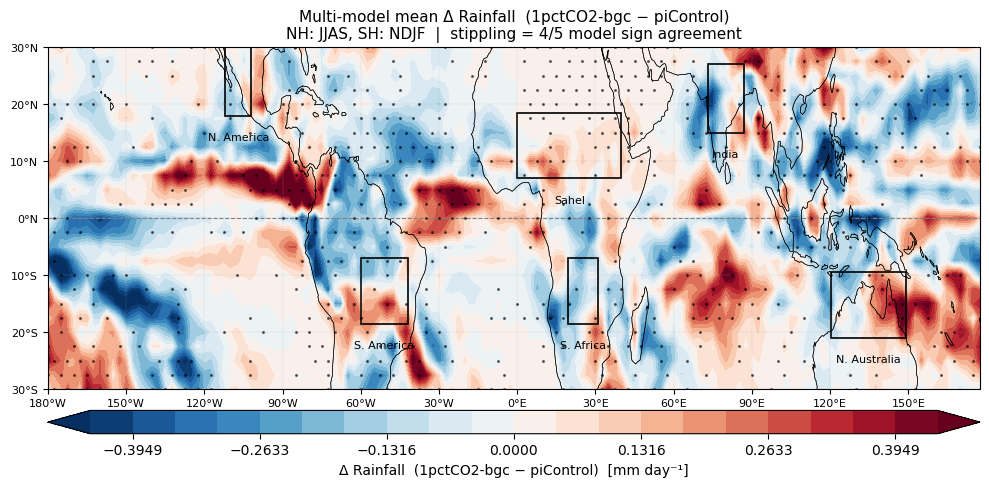

Figure saved → Rainfall_response_map_1pctCO2-bgcyrs6190_minus_piControlfirst30yrs.png
Returning → Rainfall_response_map_1pctCO2-bgcyrs6190_minus_piControlfirst30yrs


In [3]:
delta_mean, stipple_mask = compute_regional_map(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    agreement_threshold=4,   # 3/4 models
    save_fig=True,
    trop_bound=30,
)

In [5]:
# Save
# delta_mean.to_netcdf('/gws/ssde/j25b/impose/bidyut/analysis_transient_data/Rainfall_response_1pctCO2-bgcyrs6190_minus_piControlfirst30yrs.nc')
delta_mean.to_netcdf(f'/gws/ssde/j25b/impose/bidyut/analysis_transient_data/Rainfall_response_{EXP1}_minus_{EXP2}_monsoon.nc')

In [6]:
def compute_regional_map_all_season(
    all_results,
    exp1,
    exp2,
    trop_bound=50,
    land_mask=None,
    agreement_threshold=3,
    plot=True,
    save_fig=False,
    fig_path=None,
):
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import cartopy.io.shapereader as shpreader
    import xarray as xr
    import warnings
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    import matplotlib.patches as mpatches

    label1   = _exp_year_label(exp1)
    label2   = _exp_year_label(exp2)
    var_name = f"Rainfall_response_map_{exp1}{label1}_minus_{exp2}{label2}"

    # ------------------------------------------------------------------ #
    # 1.  Build per-model delta fields (exp1 - exp2) for all seasons
    # ------------------------------------------------------------------ #
    seasonal_delta_lists = {"SUM": [], "WIN": [], "ANN": []}

    for model_name, results in all_results.items():
        if exp1 not in results or exp2 not in results:
            warnings.warn(f"Model '{model_name}' missing '{exp1}' or '{exp2}' — skipped.")
            continue

        for season in ("SUM", "WIN", "ANN"):
            mean1 = results[exp1][season]["mean"]
            mean2 = results[exp2][season]["mean"]
            delta_by_season = mean1 - mean2

            da_regrid = roll_lon(regrid_to_common(delta_by_season, target_lat=trop_bound))
            seasonal_delta_lists[season].append(da_regrid)

    if not seasonal_delta_lists["SUM"]:
        raise ValueError(f"No models with data for both '{exp1}' and '{exp2}' found.")

    n_models = len(seasonal_delta_lists["SUM"])

    # ------------------------------------------------------------------ #
    # 2.  Compute multi-model means and stipple masks for each season
    # ------------------------------------------------------------------ #
    
    seasonal_results = {}
    
    for season in ["SUM", "WIN", "ANN"]:
        stacked = xr.concat(seasonal_delta_lists[season], dim="model")
        delta_mean_season = stacked.mean(dim="model").squeeze()
        
        sign_mean = np.sign(delta_mean_season.values)
        sign_models = np.sign(stacked.values)
        n_agree = np.sum(sign_models == sign_mean[np.newaxis, :, :], axis=0)
        stipple_mask_season = n_agree >= agreement_threshold
        
        seasonal_results[season] = {
            'delta_mean': delta_mean_season,
            'stipple_mask': stipple_mask_season,
        }

    # ------------------------------------------------------------------ #
    # 3.  For plotting: create stitched version (NH=SUM, SH=WIN)
    # ------------------------------------------------------------------ #
    
    lat = seasonal_results["SUM"]['delta_mean'].lat
    lon = seasonal_results["SUM"]['delta_mean'].lon
    
    delta_mean_stitched = xr.where(lat > 0, 
                                    seasonal_results["SUM"]['delta_mean'], 
                                    seasonal_results["WIN"]['delta_mean'])
    delta_mean_stitched = delta_mean_stitched.squeeze()
    
    # For plotting stipple mask, use stitched version
    # Create 2D lat array for broadcasting
    LAT_2D, _ = np.meshgrid(lon.values, lat.values)
    stipple_mask_stitched = np.where(LAT_2D > 0,
                                      seasonal_results["SUM"]['stipple_mask'],
                                      seasonal_results["WIN"]['stipple_mask'])

    lat  = delta_mean_stitched.lat.values
    lon  = delta_mean_stitched.lon.values
    data = delta_mean_stitched.values
    LON, LAT = np.meshgrid(lon, lat)

    # ------------------------------------------------------------------ #
    # 4.  Plot (using stitched version)
    # ------------------------------------------------------------------ #
    if plot:
        vmax = float(np.nanpercentile(np.abs(data), 98))
        vmin = -vmax
        levels = np.linspace(-vmax, vmax, 21)

        import cartopy.crs as ccrs
        import cartopy.feature as cfeature
        fig, ax = plt.subplots(figsize=(10, 5),
                               subplot_kw={"projection": ccrs.PlateCarree()})
        ax.add_feature(cfeature.COASTLINE, linewidth=0.3)
        ax.set_global()

        im = ax.contourf(LON, LAT, data, levels=levels, cmap='RdBu_r',
                     extend='both', transform=ccrs.PlateCarree())

        # Stippling (using stitched stipple mask)
        stip_lat_flat = LAT[stipple_mask_stitched].ravel()[::2]
        stip_lon_flat = LON[stipple_mask_stitched].ravel()[::2]
        ax.scatter(stip_lon_flat, stip_lat_flat,
                   s=1.5, color="black", alpha=0.5, zorder=5)

        # Coastlines
        try:
            shpfilename = shpreader.natural_earth(
                resolution="110m", category="physical", name="coastline"
            )
            reader = shpreader.Reader(shpfilename)
            for geom in reader.geometries():
                if hasattr(geom, "geoms"):
                    for g in geom.geoms:
                        ax.plot(*g.xy, color="black", linewidth=0.5, zorder=4)
                else:
                    ax.plot(*geom.xy, color="black", linewidth=0.5, zorder=4)
        except Exception:
            pass

        cbar = plt.colorbar(im, ax=ax, orientation="horizontal", 
                            pad=0.05, shrink=1.0, aspect=40)
        cbar.set_label(f"Δ Rainfall  ({exp1} − {exp2})  [mm day⁻¹]", fontsize=10)

        # Equator line
        ax.plot([float(lon.min()), float(lon.max())], [0, 0],
            color='gray', linewidth=0.8, linestyle='--',
            transform=ccrs.PlateCarree())
    
        ax.set_extent([float(lon.min()), float(lon.max()),
                       float(lat.min()), float(lat.max())], crs=ccrs.PlateCarree())
        ax.set_aspect('auto')
    
        ax.set_xticks(np.arange(np.floor(float(lon.min())),
                                np.ceil(float(lon.max()))+1, 30), crs=ccrs.PlateCarree())
        ax.set_yticks(np.arange(np.floor(float(lat.min())),
                                np.ceil(float(lat.max()))+1, 10), crs=ccrs.PlateCarree())
        ax.xaxis.set_major_formatter(LongitudeFormatter())
        ax.yaxis.set_major_formatter(LatitudeFormatter())
        ax.tick_params(labelsize=8)

        ax.set_xlim(lon.min(), lon.max())
        ax.set_ylim(lat.min(), lat.max())
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"{int(x)}°E" if x >= 0 else f"{int(-x)}°W"))
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(
            lambda y, _: f"{int(y)}°N" if y >= 0 else f"{int(-y)}°S"))
        ax.set_title(
            f"Multi-model mean Δ Rainfall  ({exp1} − {exp2})\n"
            f"NH: JJAS, SH: NDJF  |  "
            f"stippling = {agreement_threshold}/{n_models} model sign agreement",
            fontsize=11
        )
        ax.grid(True, linewidth=0.3, alpha=0.4)

        # Bombardi and Boos 2021 regions
        regions = {
            'N. America':   {'lon': (248, 258),  'lat': (18,    33)},
            'S. America':   {'lon': (300, 318),  'lat': (-18.5, -7)},
            'Sahel':        {'lon': (0,   40),   'lat': (7,   18.5)},
            'S. Africa':    {'lon': (19.5, 31),  'lat': (-18.5, -7)},
            'India':        {'lon': (73,  87),   'lat': (15,    27)},
            'N. Australia': {'lon': (120.5, 149),'lat': (-21,  -9.5)},
        }
        for name, coords in regions.items():
            lon0, lon1 = coords['lon']
            lat0, lat1 = coords['lat']
            rect = mpatches.Rectangle(
                (lon0, lat0), lon1-lon0, lat1-lat0,
                linewidth=1.2, edgecolor='black', facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax.add_patch(rect)
            ax.text(lon0+(lon1-lon0)/2, lat0-3, name,
                    fontsize=8, ha='center', va='top',
                    transform=ccrs.PlateCarree())

        plt.tight_layout()
        plt.show()

        if save_fig:
            path = fig_path or f"{var_name}.png"
            fig.savefig(path, dpi=150, bbox_inches="tight")
            print(f"Figure saved → {path}")

    print(f"Returning → {var_name}")
    
    # Return all seasons as a single xarray Dataset
    delta_mean = xr.Dataset({
        'SUM': seasonal_results['SUM']['delta_mean'],
        'WIN': seasonal_results['WIN']['delta_mean'],
        'ANN': seasonal_results['ANN']['delta_mean'],
    })
    
    return delta_mean

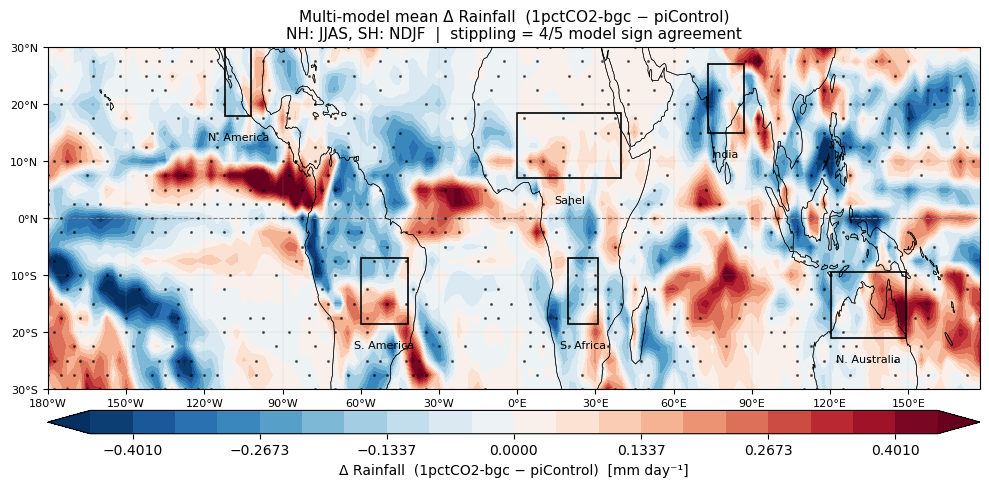

Returning → Rainfall_response_map_1pctCO2-bgcyrs6190_minus_piControlfirst30yrs


In [7]:
delta_mean = compute_regional_map_all_season(
    all_results,
    exp1=EXP1,
    exp2=EXP2,
    agreement_threshold=4,   # 3/4 models
    save_fig=False,
    trop_bound=30,
)

In [8]:
# Save
delta_mean.to_netcdf(f'/gws/ssde/j25b/impose/bidyut/analysis_transient_data/Rainfall_response_{EXP1}_minus_{EXP2}_all_seasons.nc')